# Customer Review Intelligence: Sentiment Analysis and Topic Modeling

## Project Setup

In [4]:
# Core
import os
import re
import string
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)

# Topic modeling
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Load Dataset

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews


In [6]:
import os

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


In [7]:
df = pd.read_csv(os.path.join(path, "Reviews.csv"))
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [8]:
print("Shape:", df.shape)

display(df.head())
display(df.info())
display(df.isnull().sum())
display(df["Score"].value_counts().sort_index())

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


None

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [9]:
def label_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["Sentiment"] = df["Score"].apply(label_sentiment)

df[["Score", "Sentiment"]].head()

,Score,Sentiment
0,5,positive
1,1,negative
2,4,positive
3,2,negative
4,5,positive


## Initial Data Inspection

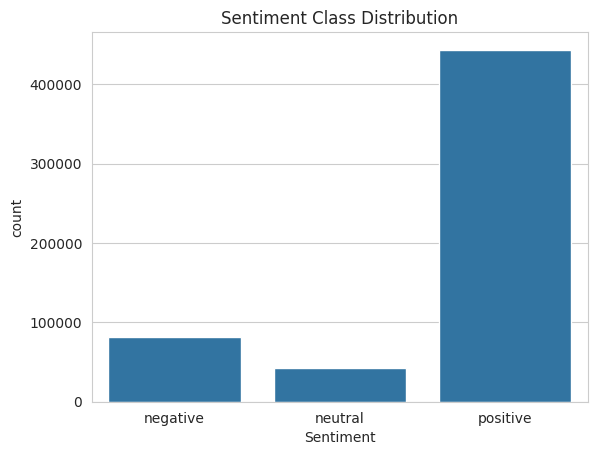

Sentiment
positive    0.780674
negative    0.144316
neutral     0.075010
Name: proportion, dtype: float64

In [10]:
sns.countplot(data=df, x="Sentiment", order=["negative", "neutral", "positive"])
plt.title("Sentiment Class Distribution")
plt.show()

df["Sentiment"].value_counts(normalize=True)

In [11]:
df_sample = df.sample(n=50000, random_state=42)

In [12]:
print("Shape:", df.shape)

display(df.head())
display(df.info())
display(df.isnull().sum())
display(df["Score"].value_counts().sort_index())

Shape: (568454, 11)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,positive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
 10  Sentiment               568454 non-null  object
dtypes: int64(5), object(6)
memory usage: 47.7+ MB


None

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
Sentiment                  0
dtype: int64

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [13]:
df_clean = df[
    [
        "Id",
        "ProductId",
        "UserId",
        "Score",
        "Summary",
        "Text",
        "HelpfulnessNumerator",
        "HelpfulnessDenominator",
        "Time"
    ]
].copy()

df_clean.head()

,Id,ProductId,UserId,Score,Summary,Text,HelpfulnessNumerator,HelpfulnessDenominator,Time
0,1,B001E4KFG0,A3SGXH7AUHU8GW,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1,1,1303862400
1,2,B00813GRG4,A1D87F6ZCVE5NK,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0,0,1346976000
2,3,B000LQOCH0,ABXLMWJIXXAIN,4,"""Delight"" says it all",This is a confection that has been around a fe...,1,1,1219017600
3,4,B000UA0QIQ,A395BORC6FGVXV,2,Cough Medicine,If you are looking for the secret ingredient i...,3,3,1307923200
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,5,Great taffy,Great taffy at a great price. There was a wid...,0,0,1350777600


In [14]:
def label_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df_clean["Sentiment"] = df_clean["Score"].apply(label_sentiment)

display(df_clean[["Score", "Sentiment", "Text"]].head())
display(df_clean["Sentiment"].value_counts())

,Score,Sentiment,Text
0,5,positive,I have bought several of the Vitality canned d...
1,1,negative,Product arrived labeled as Jumbo Salted Peanut...
2,4,positive,This is a confection that has been around a fe...
3,2,negative,If you are looking for the secret ingredient i...
4,5,positive,Great taffy at a great price. There was a wid...


Sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

## Data Cleaning and Feature Engineering

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df_clean["CleanedText"] = df_clean["Text"].apply(clean_text)

df_clean[["Text", "CleanedText"]].head()

,Text,CleanedText
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut pe...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [16]:
df_model = df_clean.sample(n=50000, random_state=42)

df_model["Sentiment"].value_counts(normalize=True)

Sentiment
positive    0.78210
negative    0.14208
neutral     0.07582
Name: proportion, dtype: float64

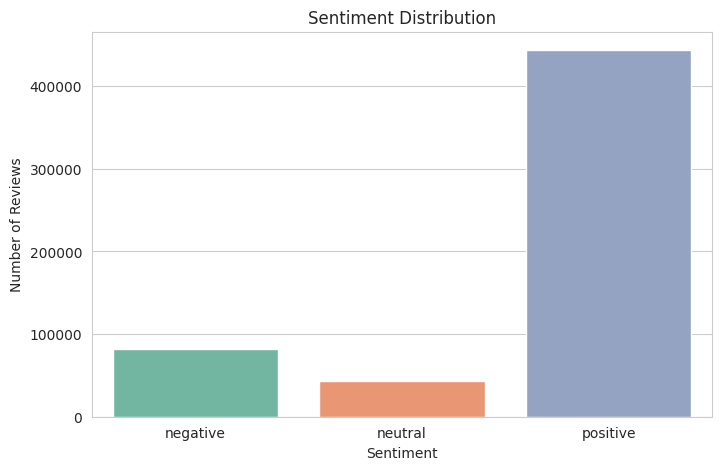

Sentiment
negative    0.144
neutral     0.075
positive    0.781
Name: proportion, dtype: float64

In [17]:
sentiment_order = ["negative", "neutral", "positive"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Sentiment",
    hue="Sentiment",
    order=sentiment_order,
    hue_order=sentiment_order,
    palette="Set2",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

display(
    df_clean["Sentiment"]
    .value_counts(normalize=True)
    .reindex(sentiment_order)
    .round(3)
)

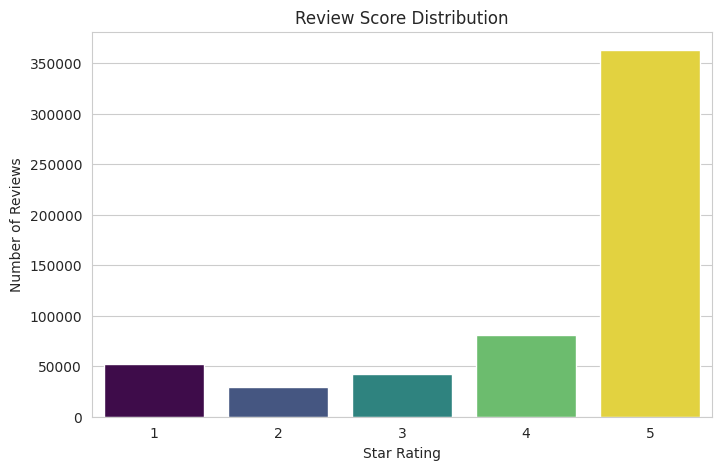

Score
1    0.092
2    0.052
3    0.075
4    0.142
5    0.639
Name: proportion, dtype: float64

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Score",
    hue="Score",
    palette="viridis",
    legend=False
)

plt.title("Review Score Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

display(df_clean["Score"].value_counts(normalize=True).sort_index().round(3))

## Exploratory Data Analysis

In [19]:
df_clean["ReviewLength"] = df_clean["Text"].astype(str).str.len()
df_clean["WordCount"] = df_clean["Text"].astype(str).str.split().str.len()

display(df_clean[["Text", "ReviewLength", "WordCount"]].head())

,Text,ReviewLength,WordCount
0,I have bought several of the Vitality canned d...,263,48
1,Product arrived labeled as Jumbo Salted Peanut...,190,31
2,This is a confection that has been around a fe...,509,94
3,If you are looking for the secret ingredient i...,219,41
4,Great taffy at a great price. There was a wid...,140,27


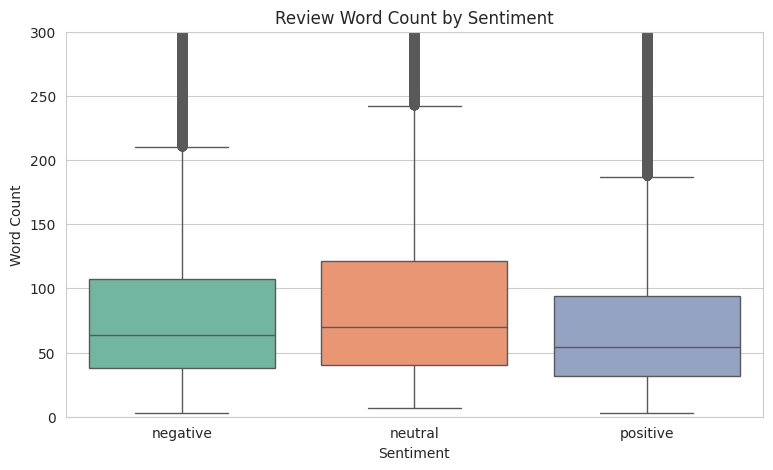

,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
negative,82037.0,88.3,89.1,3.0,38.0,64.0,107.0,2149.0
neutral,42640.0,95.6,89.6,7.0,40.0,70.0,121.0,3432.0
positive,443777.0,77.3,76.2,3.0,32.0,54.0,94.0,2520.0


In [20]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Sentiment",
    y="WordCount",
    hue="Sentiment",
    order=sentiment_order,
    hue_order=sentiment_order,
    palette="Set2",
    legend=False
)

plt.title("Review Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.ylim(0, 300)
plt.show()

display(
    df_clean.groupby("Sentiment")["WordCount"]
    .describe()
    .round(1)
    .loc[sentiment_order]
)

,HelpfulnessNumerator,HelpfulnessDenominator,HelpfulnessRatio
0,1,1,1.0
1,0,0,NaN
2,1,1,1.0
3,3,3,1.0
4,0,0,NaN


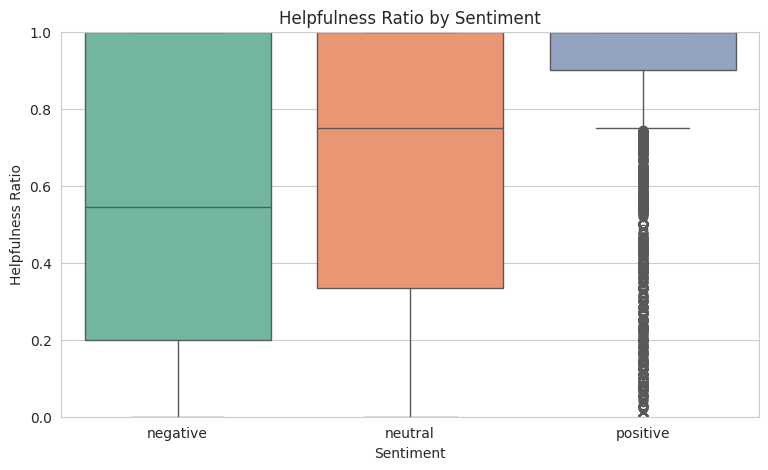

In [21]:
df_clean["HelpfulnessRatio"] = np.where(
    df_clean["HelpfulnessDenominator"] > 0,
    df_clean["HelpfulnessNumerator"] / df_clean["HelpfulnessDenominator"],
    np.nan
)

display(df_clean[["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]].head())

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Sentiment",
    y="HelpfulnessRatio",
    hue="Sentiment",
    order=sentiment_order,
    hue_order=sentiment_order,
    palette="Set2",
    legend=False
)

plt.title("Helpfulness Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Helpfulness Ratio")
plt.ylim(0, 1)
plt.show()

In [22]:
from collections import Counter

def get_top_words(text_series, n=20):
    all_words = " ".join(text_series.dropna()).split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(n), columns=["Word", "Count"])

positive_words = get_top_words(
    df_clean[df_clean["Sentiment"] == "positive"]["CleanedText"],
    n=20
)

negative_words = get_top_words(
    df_clean[df_clean["Sentiment"] == "negative"]["CleanedText"],
    n=20
)

display(positive_words)
display(negative_words)

,Word,Count
0,like,194902
1,good,161607
2,taste,154484
3,great,150653
4,one,146179
5,love,145781
6,flavor,142181
7,coffee,133247
8,product,126891
9,tea,124211


,Word,Count
0,like,45589
1,product,40355
2,taste,40082
3,one,30630
4,would,27022
5,food,26005
6,flavor,25321
7,coffee,23824
8,good,21906
9,dog,18008


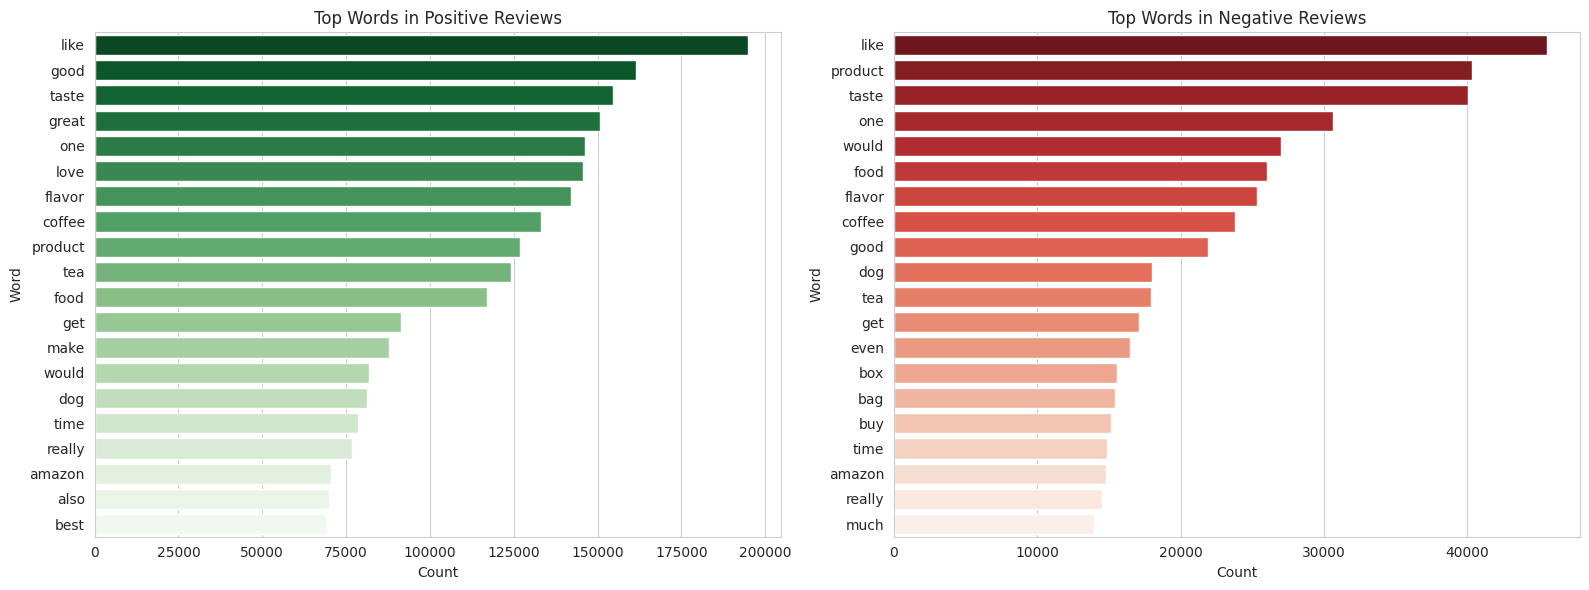

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=positive_words,
    x="Count",
    y="Word",
    hue="Word",
    ax=axes[0],
    palette="Greens_r",
    legend=False
)
axes[0].set_title("Top Words in Positive Reviews")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Word")

sns.barplot(
    data=negative_words,
    x="Count",
    y="Word",
    hue="Word",
    ax=axes[1],
    palette="Reds_r",
    legend=False
)
axes[1].set_title("Top Words in Negative Reviews")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()

In [24]:
for sentiment in sentiment_order:
    print(f"\nSample {sentiment.upper()} reviews:")
    sample_reviews = (
        df_clean[df_clean["Sentiment"] == sentiment]["Text"]
        .sample(3, random_state=42)
        .values
    )
    
    for i, review in enumerate(sample_reviews, start=1):
        print(f"\nReview {i}:")
        print(review[:500])


Sample NEGATIVE reviews:

Review 1:
I have an absolute passion for deep, dark hot chocolate. I want chocolate which tastes like *chocolate*, rich and flavorful, with a hint of a bite. You can savor chocolate like that.<br />What I have an aversion to is hot sugar. And, most hot mixes taste just like that; you might as well suck on a cube of sugar with a sprinkling of coca on top than drink a cup.<br />Regrettably, McSteven's Dark Chocolate European Coca Mix fell into the latter category. It had a bit more chocolate than, say, Nest

Review 2:
This drink is so "super energy" it's almost frightening.  Several members of my family tasted it and the consensus was that it might, indeed, give you a boost but the taste...some even compared it to grapefruit juice...was  definitely not good.

Review 3:
I'm sticking with what used to be carnation, now nestles malt. this stuff tastes like powdered milk with a hint of soy.

Sample NEUTRAL reviews:

Review 1:
These were a great price that's why I g

## Baseline Sentiment Classification Model

In [25]:
df_model = df_clean[["CleanedText", "Sentiment"]].dropna().copy()

df_model = df_model[df_model["CleanedText"].str.strip() != ""]

print("Modeling dataset shape:", df_model.shape)
display(df_model["Sentiment"].value_counts(normalize=True).round(3))

Modeling dataset shape: (568453, 2)


Sentiment
positive    0.781
negative    0.144
neutral     0.075
Name: proportion, dtype: float64

In [26]:
df_model_sample = df_model.sample(
    n=min(50000, len(df_model)),
    random_state=42
)

print("Sample shape:", df_model_sample.shape)
display(df_model_sample["Sentiment"].value_counts(normalize=True).round(3))

Sample shape: (50000, 2)


Sentiment
positive    0.783
negative    0.142
neutral     0.075
Name: proportion, dtype: float64

In [27]:
X = df_model_sample["CleanedText"]
y = df_model_sample["Sentiment"]

print("Feature examples:")
display(X.head())

print("Target examples:")
display(y.head())

Feature examples:


165254    got expecting much realy good gluten free grea...
356329    love supplement helped stress improve quality ...
427944    corousel great hold average carousel compact e...
249750    shipped insulated styrofoam cold pack included...
379071    prefer blend seasoning live longer option good...
Name: CleanedText, dtype: object

Target examples:


165254    positive
356329    positive
427944    positive
249750     neutral
379071    positive
Name: Sentiment, dtype: object

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

display(y_train.value_counts(normalize=True).round(3))
display(y_test.value_counts(normalize=True).round(3))

Training set size: 40000
Testing set size: 10000


Sentiment
positive    0.783
negative    0.142
neutral     0.075
Name: proportion, dtype: float64

Sentiment
positive    0.783
negative    0.142
neutral     0.075
Name: proportion, dtype: float64

In [29]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=5,
                                 ngram_range=(1, 2))),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [30]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=5,
                                 ngram_range=(1, 2))),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [31]:
y_pred = baseline_model.predict(X_test)

display(pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Review": X_test.values[:10]
}))

,Actual,Predicted,Review
0,negative,negative,food best spring changed formula check website...
1,positive,positive,say product delicious addictive reasonably pri...
2,positive,positive,recently home friend serving delicious cherry ...
3,positive,positive,gave four star based husband comment made tast...
4,positive,positive,buying least two year make great peanut butter...
5,negative,negative,wish read two review picked local store buck d...
6,positive,negative,great price went last subscribe save shipment ...
7,positive,positive,good coffee get bitter use sparingly satisfied
8,positive,positive,child attended tea local museum spring stash j...
9,positive,positive,nice small size treat help big dog watch waist...


In [32]:
accuracy = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.3f}")
print(f"Weighted F1 Score: {weighted_f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.804
Weighted F1 Score: 0.824

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.72      0.66      1421
     neutral       0.28      0.50      0.36       746
    positive       0.95      0.85      0.90      7833

    accuracy                           0.80     10000
   macro avg       0.61      0.69      0.64     10000
weighted avg       0.85      0.80      0.82     10000



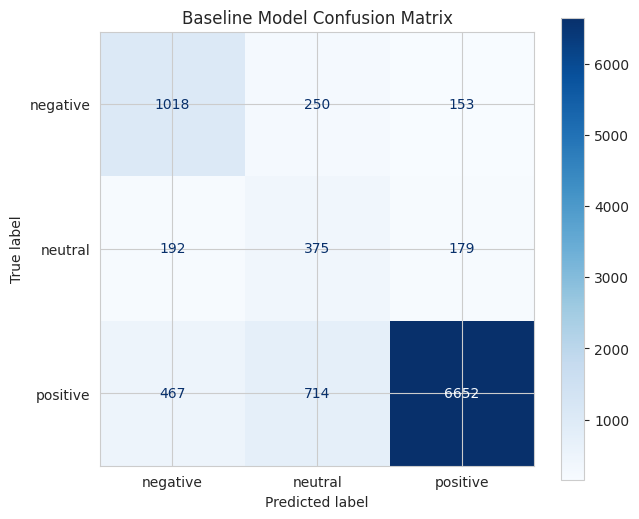

In [33]:
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Baseline Model Confusion Matrix")
plt.show()

In [34]:
custom_reviews = [
    "This product tasted amazing and I would definitely buy it again.",
    "The package arrived damaged and the food tasted stale.",
    "It was okay, nothing special but not terrible either."
]

custom_predictions = baseline_model.predict(custom_reviews)

pd.DataFrame({
    "Review": custom_reviews,
    "Predicted Sentiment": custom_predictions
})

,Review,Predicted Sentiment
0,This product tasted amazing and I would defini...,positive
1,The package arrived damaged and the food taste...,neutral
2,"It was okay, nothing special but not terrible ...",neutral


## Model Comparison

In [35]:
from sklearn.svm import LinearSVC

In [36]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

In [37]:
model_results = []

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=5
        )),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    weighted_f1 = f1_score(y_test, predictions, average="weighted")
    macro_f1 = f1_score(y_test, predictions, average="macro")
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1
    })
    
    trained_models[model_name] = pipeline

model_results_df = pd.DataFrame(model_results).sort_values(
    by="Weighted F1",
    ascending=False
)

display(model_results_df.round(3))

,Model,Accuracy,Weighted F1,Macro F1
2,Linear SVC,0.849,0.849,0.658
0,Logistic Regression,0.804,0.824,0.638
1,Multinomial Naive Bayes,0.809,0.744,0.403


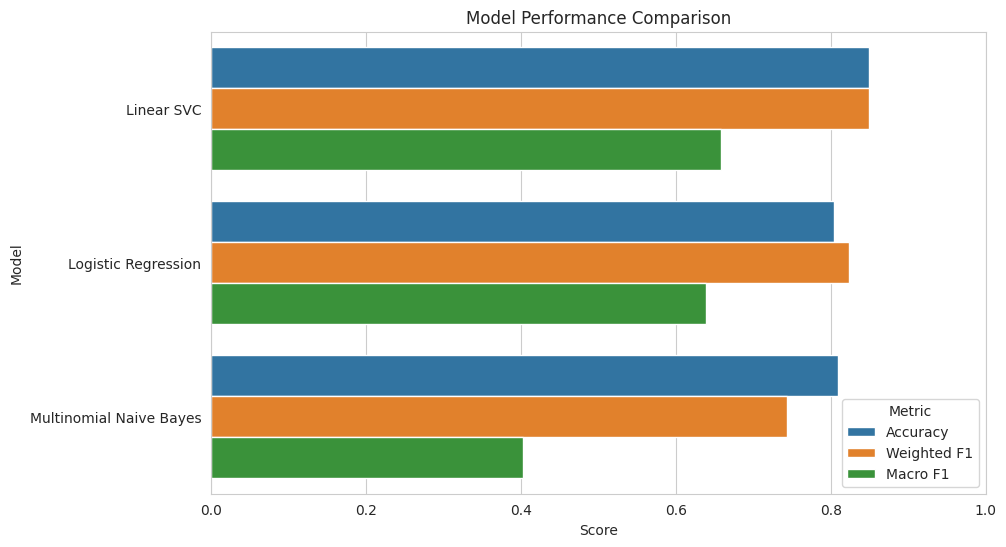

In [38]:
model_results_melted = model_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Weighted F1", "Macro F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results_melted,
    x="Score",
    y="Model",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.show()

In [39]:
best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Linear SVC


In [40]:
best_predictions = best_model.predict(X_test)

print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, best_predictions))

Classification Report for Linear SVC:
              precision    recall  f1-score   support

    negative       0.68      0.68      0.68      1421
     neutral       0.37      0.37      0.37       746
    positive       0.93      0.93      0.93      7833

    accuracy                           0.85     10000
   macro avg       0.66      0.66      0.66     10000
weighted avg       0.85      0.85      0.85     10000



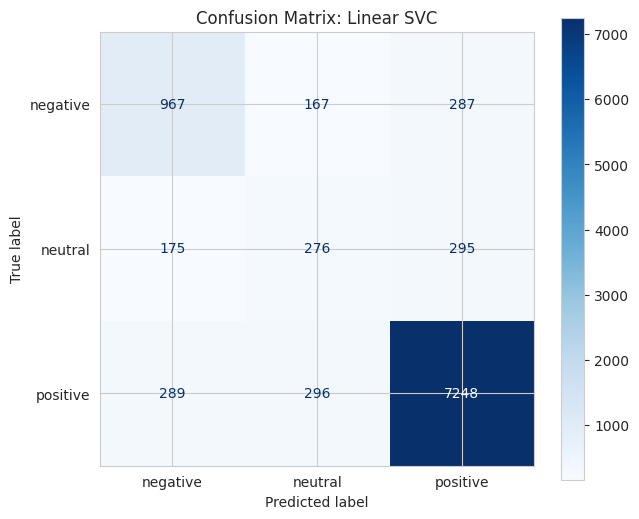

In [41]:
labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, best_predictions, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [42]:
df_binary = df_model_sample[df_model_sample["Sentiment"] != "neutral"].copy()

X_binary = df_binary["CleanedText"]
y_binary = df_binary["Sentiment"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

binary_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5
    )),
    ("model", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

binary_model.fit(X_train_bin, y_train_bin)

y_pred_bin = binary_model.predict(X_test_bin)

print("Binary Sentiment Model")
print("Accuracy:", round(accuracy_score(y_test_bin, y_pred_bin), 3))
print("Weighted F1:", round(f1_score(y_test_bin, y_pred_bin, average="weighted"), 3))
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_bin))

Binary Sentiment Model
Accuracy: 0.918
Weighted F1: 0.92

Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.80      0.75      1421
    positive       0.96      0.94      0.95      7833

    accuracy                           0.92      9254
   macro avg       0.83      0.87      0.85      9254
weighted avg       0.92      0.92      0.92      9254



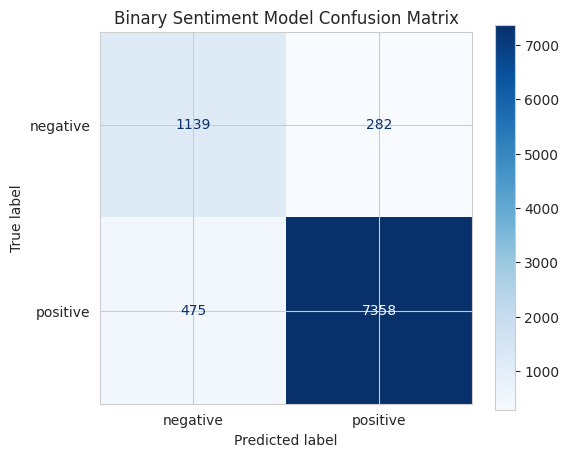

In [43]:
binary_labels = ["negative", "positive"]

cm = confusion_matrix(y_test_bin, y_pred_bin, labels=binary_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=binary_labels
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Binary Sentiment Model Confusion Matrix")
plt.show()

In [44]:
best_tfidf = best_model.named_steps["tfidf"]
best_classifier = best_model.named_steps["model"]

feature_names = np.array(best_tfidf.get_feature_names_out())
class_labels = best_classifier.classes_

print("Classes:", class_labels)
print("Number of TF-IDF features:", len(feature_names))

Classes: ['negative' 'neutral' 'positive']
Number of TF-IDF features: 20000


In [45]:
def get_top_terms_for_class(class_index, n=20):
    class_coefficients = best_classifier.coef_[class_index]
    
    top_positive_indices = class_coefficients.argsort()[-n:][::-1]
    top_negative_indices = class_coefficients.argsort()[:n]
    
    top_positive_terms = pd.DataFrame({
        "Term": feature_names[top_positive_indices],
        "Coefficient": class_coefficients[top_positive_indices]
    })
    
    top_negative_terms = pd.DataFrame({
        "Term": feature_names[top_negative_indices],
        "Coefficient": class_coefficients[top_negative_indices]
    })
    
    return top_positive_terms, top_negative_terms

In [46]:
top_terms_by_class = {}

for i, class_label in enumerate(class_labels):
    top_terms, opposite_terms = get_top_terms_for_class(i, n=20)
    top_terms_by_class[class_label] = top_terms
    
    print(f"\nTop terms for class: {class_label}")
    display(top_terms)


Top terms for class: negative


,Term,Coefficient
0,awful,3.618099
1,horrible,3.586739
2,two star,3.560572
3,disappointment,3.548118
4,worst,3.462961
5,never buy,2.970452
6,might good,2.927476
7,way sweet,2.897742
8,poor,2.799813
9,disappointed,2.793980



Top terms for class: neutral


,Term,Coefficient
0,three star,4.486276
1,ok,3.945282
2,okay,3.649844
3,seems little,3.063047
4,amazon order,3.024980
5,bought wife,2.866336
6,twin,2.859505
7,least favorite,2.854667
8,treat seem,2.797644
9,giving star,2.728116



Top terms for class: positive


,Term,Coefficient
0,perfect,3.858800
1,great,3.698521
2,best,3.456330
3,delicious,3.413043
4,love,3.331892
5,hooked,2.529609
6,excellent,2.517058
7,wonderful,2.470438
8,highly recommend,2.451039
9,highly,2.400460


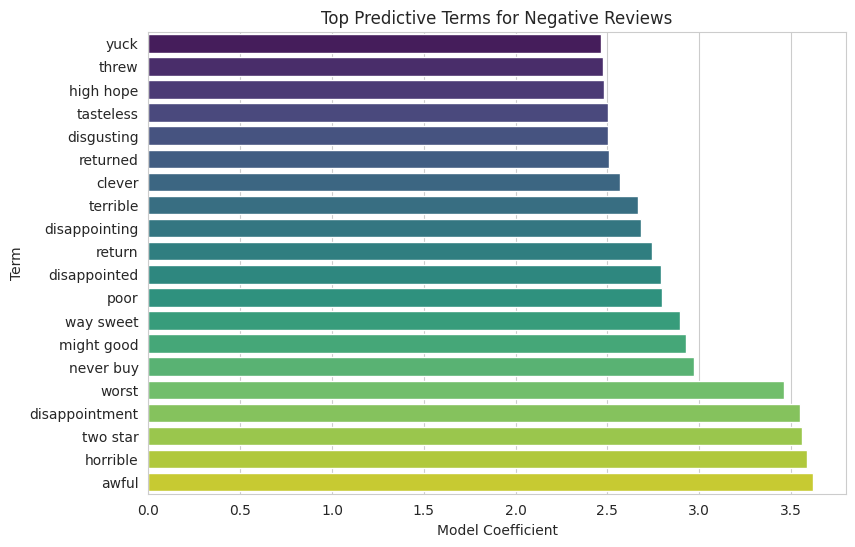

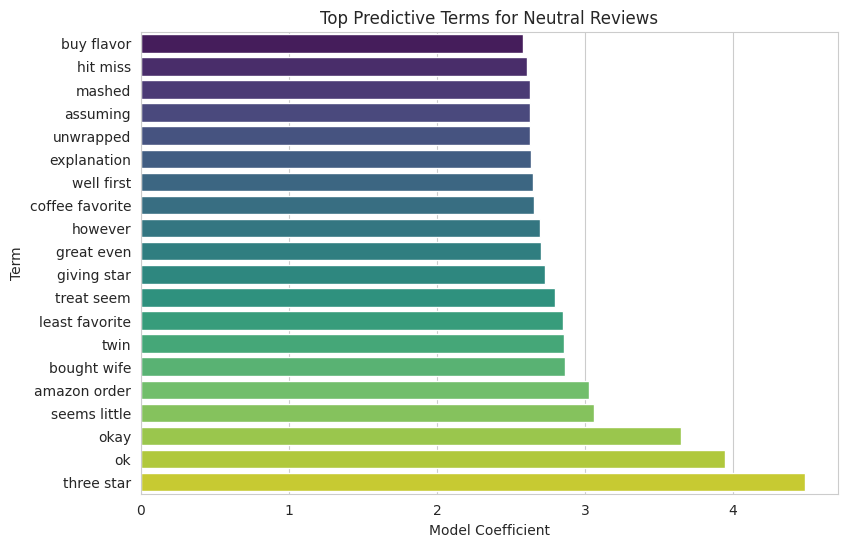

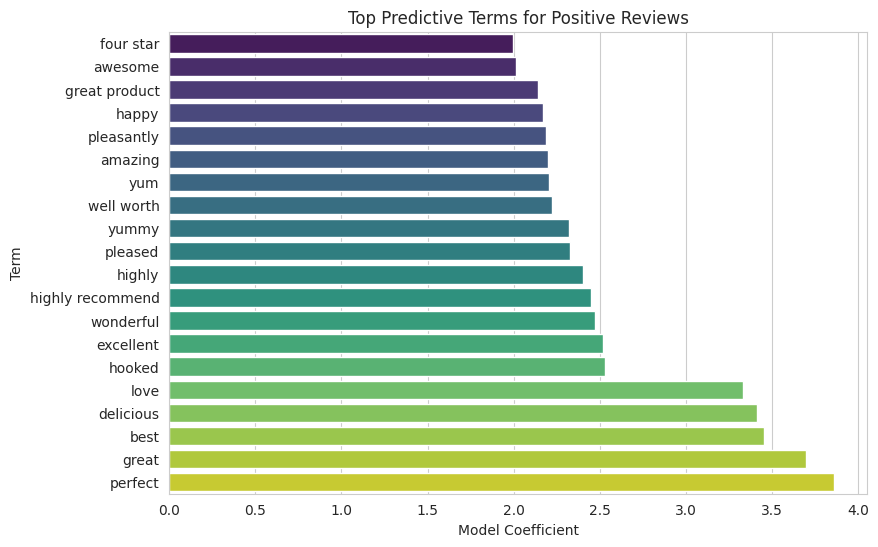

In [47]:
for class_label, terms_df in top_terms_by_class.items():
    plt.figure(figsize=(9, 6))
    
    sns.barplot(
        data=terms_df.sort_values("Coefficient"),
        x="Coefficient",
        y="Term",
        hue="Term",
        palette="viridis",
        legend=False
    )
    
    plt.title(f"Top Predictive Terms for {class_label.capitalize()} Reviews")
    plt.xlabel("Model Coefficient")
    plt.ylabel("Term")
    plt.show()

##  Model Interpretation

In [48]:
interpretation_examples = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

interpretation_examples["Correct"] = (
    interpretation_examples["Actual"] == interpretation_examples["Predicted"]
)

display(interpretation_examples.head())

,Review,Actual,Predicted,Correct
0,food best spring changed formula check website...,negative,negative,True
1,say product delicious addictive reasonably pri...,positive,positive,True
2,recently home friend serving delicious cherry ...,positive,positive,True
3,gave four star based husband comment made tast...,positive,positive,True
4,buying least two year make great peanut butter...,positive,positive,True


## Binary Sentiment Classification

In [49]:
misclassified_reviews = interpretation_examples[
    interpretation_examples["Correct"] == False
].copy()

print("Number of misclassified reviews:", misclassified_reviews.shape[0])

display(
    misclassified_reviews[
        ["Actual", "Predicted", "Review"]
    ].sample(10, random_state=42)
)

Number of misclassified reviews: 1509


,Actual,Predicted,Review
3963,negative,neutral,product description correct offering bottle pr...
7590,neutral,positive,usually order package every couple month labra...
2541,positive,negative,kettle brand chip crunchy would say regular pl...
3989,positive,neutral,got christmas super excited baked yesterday ma...
6492,neutral,negative,bone massive probably biggest bone ever seen l...
7793,positive,neutral,package arrived time however pack ripped satis...
1168,negative,neutral,nut mix okay taste sprinkled blueberry dust pa...
7202,neutral,positive,bought pack left tried never finished single p...
4800,neutral,negative,coffee snob appreciate good cup robust freshly...
7314,positive,neutral,favorite creme brulee dark roast sweet smooth ...


In [50]:
misclassified_reviews = interpretation_examples[
    interpretation_examples["Correct"] == False
].copy()

print("Number of misclassified reviews:", misclassified_reviews.shape[0])

display(
    misclassified_reviews[
        ["Actual", "Predicted", "Review"]
    ].sample(10, random_state=42)
)

Number of misclassified reviews: 1509


,Actual,Predicted,Review
3963,negative,neutral,product description correct offering bottle pr...
7590,neutral,positive,usually order package every couple month labra...
2541,positive,negative,kettle brand chip crunchy would say regular pl...
3989,positive,neutral,got christmas super excited baked yesterday ma...
6492,neutral,negative,bone massive probably biggest bone ever seen l...
7793,positive,neutral,package arrived time however pack ripped satis...
1168,negative,neutral,nut mix okay taste sprinkled blueberry dust pa...
7202,neutral,positive,bought pack left tried never finished single p...
4800,neutral,negative,coffee snob appreciate good cup robust freshly...
7314,positive,neutral,favorite creme brulee dark roast sweet smooth ...


In [51]:
neutral_mistakes = misclassified_reviews[
    misclassified_reviews["Actual"] == "neutral"
].copy()

print("Misclassified neutral reviews:", neutral_mistakes.shape[0])

display(
    neutral_mistakes[
        ["Actual", "Predicted", "Review"]
    ].sample(10, random_state=42)
)

Misclassified neutral reviews: 470


,Actual,Predicted,Review
1181,neutral,negative,thought deal time later found could get k cup ...
1525,neutral,positive,basically large fig newton cherry flavored als...
725,neutral,negative,bought tug jug dog jealous cat slim kitty food...
9511,neutral,negative,tried first time recently budget tight willing...
9011,neutral,negative,premise drink good juice sugar added fell shor...
4916,neutral,positive,love wellness chicken formula great ingredient...
4338,neutral,positive,second child much unlike older brother extreme...
214,neutral,positive,tried whim picked local supermarket think tast...
7381,neutral,positive,product nice price right swiss chocolate sure ...
1486,neutral,negative,taste give star pretty good taste little bit l...


In [52]:
print("Model Interpretation Summary")
print("----------------------------")
print(f"Best model: {best_model_name}")
print("The model uses TF-IDF features, meaning it learns from important words and short phrases.")
print("Positive reviews are usually easier to identify because they contain strong praise words.")
print("Negative reviews are often identified by complaint-related terms.")
print("Neutral reviews are harder because they often contain mixed or mild language.")

Model Interpretation Summary
----------------------------
Best model: Linear SVC
The model uses TF-IDF features, meaning it learns from important words and short phrases.
Positive reviews are usually easier to identify because they contain strong praise words.
Negative reviews are often identified by complaint-related terms.
Neutral reviews are harder because they often contain mixed or mild language.


## Topic Modeling

In [53]:
negative_reviews = df_clean[
    (df_clean["Sentiment"] == "negative") &
    (df_clean["CleanedText"].notna()) &
    (df_clean["CleanedText"].str.strip() != "")
].copy()

negative_reviews_sample = negative_reviews.sample(
    n=min(20000, len(negative_reviews)),
    random_state=42
)

print("Negative reviews shape:", negative_reviews.shape)
print("Negative reviews sample shape:", negative_reviews_sample.shape)

Negative reviews shape: (82037, 14)
Negative reviews sample shape: (20000, 14)


In [54]:
topic_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2)
)

topic_matrix = topic_vectorizer.fit_transform(
    negative_reviews_sample["CleanedText"]
)

topic_feature_names = np.array(topic_vectorizer.get_feature_names_out())

print("Topic matrix shape:", topic_matrix.shape)

Topic matrix shape: (20000, 5000)


In [55]:
n_topics = 6

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    max_iter=10
)

lda_model.fit(topic_matrix)

LatentDirichletAllocation(n_components=6, random_state=42)

In [56]:
def display_topics(model, feature_names, n_words=12):
    topics = []
    
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = feature_names[top_indices]
        
        topics.append({
            "Topic": f"Topic {topic_idx + 1}",
            "Top Words": ", ".join(top_words)
        })
    
    return pd.DataFrame(topics)

topic_words_df = display_topics(
    lda_model,
    topic_feature_names,
    n_words=12
)

display(topic_words_df)

,Topic,Top Words
0,Topic 1,"product, taste, like, sugar, ingredient, chip,..."
1,Topic 2,"taste, like, flavor, one, good, really, chocol..."
2,Topic 3,"coffee, cup, price, like, one, good, product, ..."
3,Topic 4,"tea, food, day, green tea, eating, would, thin..."
4,Topic 5,"product, amazon, box, one, bag, time, would, o..."
5,Topic 6,"food, dog, cat, treat, product, eat, one, woul..."


In [57]:
topic_distributions = lda_model.transform(topic_matrix)

negative_reviews_sample["TopicNumber"] = topic_distributions.argmax(axis=1) + 1
negative_reviews_sample["TopicConfidence"] = topic_distributions.max(axis=1)

display(
    negative_reviews_sample[
        ["Text", "Sentiment", "TopicNumber", "TopicConfidence"]
    ].head()
)

,Text,Sentiment,TopicNumber,TopicConfidence
525327,"I have an absolute passion for deep, dark hot ...",negative,2,0.816032
75760,"This drink is so ""super energy"" it's almost fr...",negative,1,0.631991
468100,"I'm sticking with what used to be carnation, n...",negative,2,0.940197
71864,Aspertame causes alot of problems including pr...,negative,1,0.653630
211592,I ordered these because my local pet store sto...,negative,5,0.620531


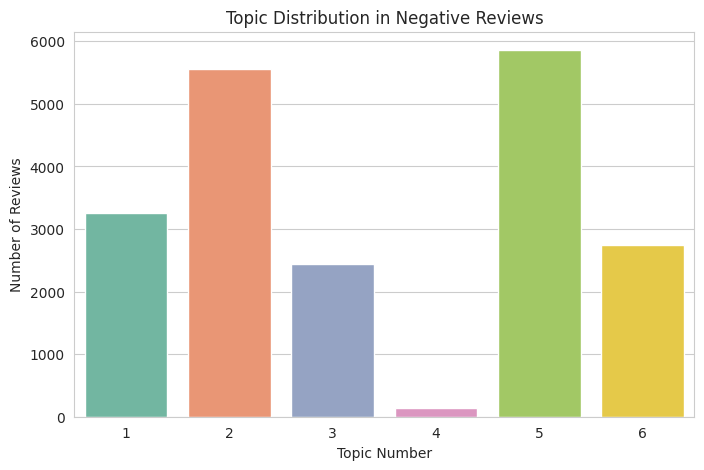

,TopicNumber,ReviewCount
0,1,3261
1,2,5562
2,3,2435
3,4,145
4,5,5859
5,6,2738


In [58]:
topic_counts = (
    negative_reviews_sample["TopicNumber"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_counts.columns = ["TopicNumber", "ReviewCount"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=topic_counts,
    x="TopicNumber",
    y="ReviewCount",
    hue="TopicNumber",
    palette="Set2",
    legend=False
)

plt.title("Topic Distribution in Negative Reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of Reviews")
plt.show()

display(topic_counts)

In [59]:
for topic_num in sorted(negative_reviews_sample["TopicNumber"].unique()):
    print(f"\nTopic {topic_num} Examples:")
    
    topic_examples = (
        negative_reviews_sample[
            negative_reviews_sample["TopicNumber"] == topic_num
        ]
        .sort_values("TopicConfidence", ascending=False)
        .head(3)
    )
    
    for i, review in enumerate(topic_examples["Text"], start=1):
        print(f"\nExample {i}:")
        print(review[:700])


Topic 1 Examples:

Example 1:
I ordered this at the asking of my wife because she is dieting. I was against it from the start, but I will make my review fair.<br />The product is not peanut butter, if you expect peanut butter than you will be disappointed. It tastes like peanut butter. If I could compare it to something it is like eating a regular Oreo and a reduced fat Oreo. The reduced Oreo tastes like and Oreo, but really just leaves you wanting the real thing. This product is no different. If you mask it will jelly and bread, the off taste becomes less noticeable, but there in lies the problem. You have to add more calories back in to make this product taste better. There by negating the fact that you have cut calori

Example 2:
I ordered this at the asking of my wife because she is dieting. I was against it from the start, but I will make my review fair.<br />The product is not peanut butter, if you expect peanut butter than you will be disappointed. It tastes like peanut butter.

In [60]:
topic_labels = {
    1: "Ingredients, sugar, and snack taste complaints",
    2: "Flavor and taste dissatisfaction",
    3: "Coffee, price, and value concerns",
    4: "Tea and dietary product complaints",
    5: "Amazon ordering, packaging, and delivery issues",
    6: "Pet food and pet treat complaints"
}

negative_reviews_sample["TopicLabel"] = negative_reviews_sample["TopicNumber"].map(topic_labels)

display(
    negative_reviews_sample[
        ["TopicNumber", "TopicLabel", "TopicConfidence", "Text"]
    ].head()
)

,TopicNumber,TopicLabel,TopicConfidence,Text
525327,2,Flavor and taste dissatisfaction,0.816032,"I have an absolute passion for deep, dark hot ..."
75760,1,"Ingredients, sugar, and snack taste complaints",0.631991,"This drink is so ""super energy"" it's almost fr..."
468100,2,Flavor and taste dissatisfaction,0.940197,"I'm sticking with what used to be carnation, n..."
71864,1,"Ingredients, sugar, and snack taste complaints",0.653630,Aspertame causes alot of problems including pr...
211592,5,"Amazon ordering, packaging, and delivery issues",0.620531,I ordered these because my local pet store sto...


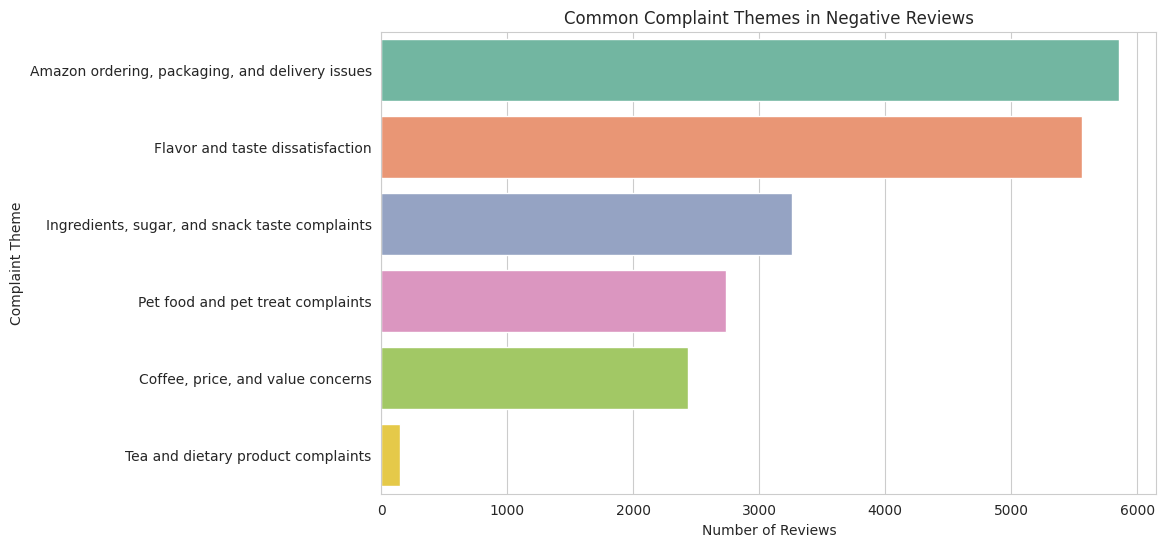

,TopicLabel,ReviewCount
0,"Amazon ordering, packaging, and delivery issues",5859
1,Flavor and taste dissatisfaction,5562
2,"Ingredients, sugar, and snack taste complaints",3261
3,Pet food and pet treat complaints,2738
4,"Coffee, price, and value concerns",2435
5,Tea and dietary product complaints,145


In [61]:
topic_label_counts = (
    negative_reviews_sample["TopicLabel"]
    .value_counts()
    .reset_index()
)

topic_label_counts.columns = ["TopicLabel", "ReviewCount"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=topic_label_counts,
    x="ReviewCount",
    y="TopicLabel",
    hue="TopicLabel",
    palette="Set2",
    legend=False
)

plt.title("Common Complaint Themes in Negative Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Complaint Theme")
plt.show()

display(topic_label_counts)

### Topic Modeling Interpretation

The LDA topic model identified several common complaint themes in negative reviews. The largest themes were pet food and treat complaints, Amazon ordering or packaging issues, and taste-related dissatisfaction. These themes suggest that negative customer experiences are not only driven by product flavor, but also by fulfillment, packaging, freshness, and product expectations.

Topic modeling adds business value because it helps move beyond sentiment classification and shows what customers are actually complaining about.

## Business Insights and Conclusions

In [62]:
sentiment_summary = (
    df_clean["Sentiment"]
    .value_counts(normalize=True)
    .reindex(["negative", "neutral", "positive"])
    .mul(100)
    .round(1)
    .reset_index()
)

sentiment_summary.columns = ["Sentiment", "Percentage"]

display(sentiment_summary)

,Sentiment,Percentage
0,negative,14.4
1,neutral,7.5
2,positive,78.1


In [63]:
final_model_summary = pd.DataFrame({
    "Metric": ["Best Model", "Accuracy", "Weighted F1 Score", "Macro F1 Score"],
    "Value": [
        best_model_name,
        round(accuracy_score(y_test, best_predictions), 3),
        round(f1_score(y_test, best_predictions, average="weighted"), 3),
        round(f1_score(y_test, best_predictions, average="macro"), 3)
    ]
})

display(final_model_summary)

,Metric,Value
0,Best Model,Linear SVC
1,Accuracy,0.849
2,Weighted F1 Score,0.849
3,Macro F1 Score,0.658


In [64]:
business_topic_summary = topic_label_counts.copy()

business_topic_summary["Percentage"] = (
    business_topic_summary["ReviewCount"] / business_topic_summary["ReviewCount"].sum() * 100
).round(1)

display(business_topic_summary)

,TopicLabel,ReviewCount,Percentage
0,"Amazon ordering, packaging, and delivery issues",5859,29.3
1,Flavor and taste dissatisfaction,5562,27.8
2,"Ingredients, sugar, and snack taste complaints",3261,16.3
3,Pet food and pet treat complaints,2738,13.7
4,"Coffee, price, and value concerns",2435,12.2
5,Tea and dietary product complaints,145,0.7


In [65]:
business_recommendations = pd.DataFrame({
    "Insight": [
        "Positive reviews dominate the dataset.",
        "Neutral reviews are difficult for the model to classify.",
        "Negative reviews reveal recurring complaint themes.",
        "Pet food and treat complaints are one of the largest negative-review topics.",
        "Ordering, packaging, and delivery issues appear frequently in negative reviews."
    ],
    "Business Recommendation": [
        "Use positive review language to identify product strengths and marketing themes.",
        "Treat neutral predictions with caution and consider routing them for manual review.",
        "Monitor negative-review topics regularly to detect product or fulfillment issues.",
        "Investigate pet product quality, ingredient concerns, and taste preferences.",
        "Improve packaging quality, delivery consistency, and product condition at arrival."
    ]
})

display(business_recommendations)

,Insight,Business Recommendation
0,Positive reviews dominate the dataset.,Use positive review language to identify produ...
1,Neutral reviews are difficult for the model to...,Treat neutral predictions with caution and con...
2,Negative reviews reveal recurring complaint th...,Monitor negative-review topics regularly to de...
3,Pet food and treat complaints are one of the l...,"Investigate pet product quality, ingredient co..."
4,"Ordering, packaging, and delivery issues appea...","Improve packaging quality, delivery consistenc..."


### Final Conclusion

This project used natural language processing to analyze Amazon Fine Food Reviews. The review ratings were converted into sentiment labels, and multiple text classification models were trained to predict whether a review was negative, neutral, or positive.

The best-performing model was Linear SVC using TF-IDF features. It performed well overall, especially for positive reviews, but struggled with neutral reviews. This limitation is expected because neutral reviews often contain mixed or mild language and are less common than positive reviews in the dataset.

Topic modeling on negative reviews added a business-focused layer to the analysis. The most common complaint themes included pet food and treat issues, ordering or packaging problems, and taste-related dissatisfaction. These findings show how NLP can help businesses move beyond overall sentiment and identify specific areas for improvement.

Overall, this project demonstrates a full NLP workflow: data cleaning, exploratory analysis, sentiment classification, model comparison, model interpretation, topic modeling, and business recommendations.